In [1]:
import os
import sys
from pathlib import Path

# Limpiar posibles rutas incorrectas heredadas
os.environ.pop("PROJ_LIB", None)
os.environ.pop("PROJ_DATA", None)

# Buscar proj.db dentro del entorno virtual activo
entorno = Path(sys.prefix)

resultados = list(entorno.rglob("proj.db"))

print("Entorno activo:")
print(entorno)

print("\nArchivos proj.db encontrados:")
for ruta in resultados:
    print(ruta)

Entorno activo:
c:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\.venv

Archivos proj.db encontrados:
c:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\.venv\Lib\site-packages\~~proj\proj_dir\share\proj\proj.db
c:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\.venv\Lib\site-packages\~yproj\proj_dir\share\proj\proj.db
c:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\.venv\Lib\site-packages\~=proj\proj_dir\share\proj\proj.db
c:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\.venv\Lib\site-packages\~.proj\proj_dir\share\proj\proj.db
c:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\.venv\Lib\site-packages\~-proj\proj_dir\share\proj\proj.db
c:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\.venv\Lib\site-packages\~%proj\proj_dir\share\proj\proj.db
c:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\.venv\Lib\site-packages\rasterio\proj_data\proj.db
c:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\.venv\Lib\site-packages\pyproj\proj_dir\share\proj\proj.db
c:\Analisis_Geo

In [2]:
import os
import sys
from pathlib import Path

entorno = Path(sys.prefix)

rutas_rasterio = [
    ruta.parent
    for ruta in entorno.rglob("proj.db")
    if "rasterio" in str(ruta).lower()
]

if not rutas_rasterio:
    raise FileNotFoundError(
        "No se encontró proj.db dentro de la instalación de rasterio."
    )

ruta_proj = rutas_rasterio[0]

os.environ["PROJ_DATA"] = str(ruta_proj)
os.environ["PROJ_LIB"] = str(ruta_proj)

print("PROJ configurado en:")
print(ruta_proj)
print("proj.db existe:", (ruta_proj / "proj.db").exists())

PROJ configurado en:
c:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\.venv\Lib\site-packages\rasterio\proj_data
proj.db existe: True


In [16]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
import os
import pyproj
import seaborn as sns
import matplotlib.patheffects as patheffects
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import ScalarFormatter
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection
from pointpats import centrography
from pointpats import QStatistic 
from pointpats import distance_statistics
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import fcluster
from scipy.stats import gaussian_kde
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.spatial.distance import cdist

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.ticker as ticker
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg

from matplotlib.patches import Patch, Rectangle
from matplotlib.lines import Line2D
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1 import make_axes_locatable

from shapely.geometry import box
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Rectangle
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
import matplotlib.ticker as ticker




In [4]:
Puntos = r"C:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\Data\Puntos\Base_datos_Completa.shp"
gdf = gpd.read_file(Puntos)
#gdf.info()
#print(gdf.crs)
gdf.set_crs(epsg=4326, inplace=True)

municipios = gpd.read_file(r"C:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\Data\Poligonos\Poligonos\Municipios_Antioquia.shp").to_crs(epsg=9377)
municipios = municipios.to_crs(9377)
gdf_proyectado = gdf.to_crs(9377)
gdf_ON = gdf.to_crs(epsg=9377)

coordenadas = np.column_stack((gdf_ON.geometry.x, gdf_ON.geometry.y))

In [5]:
from rasterio.crs import CRS

crs_prueba = CRS.from_epsg(9377)
print(crs_prueba)

EPSG:9377


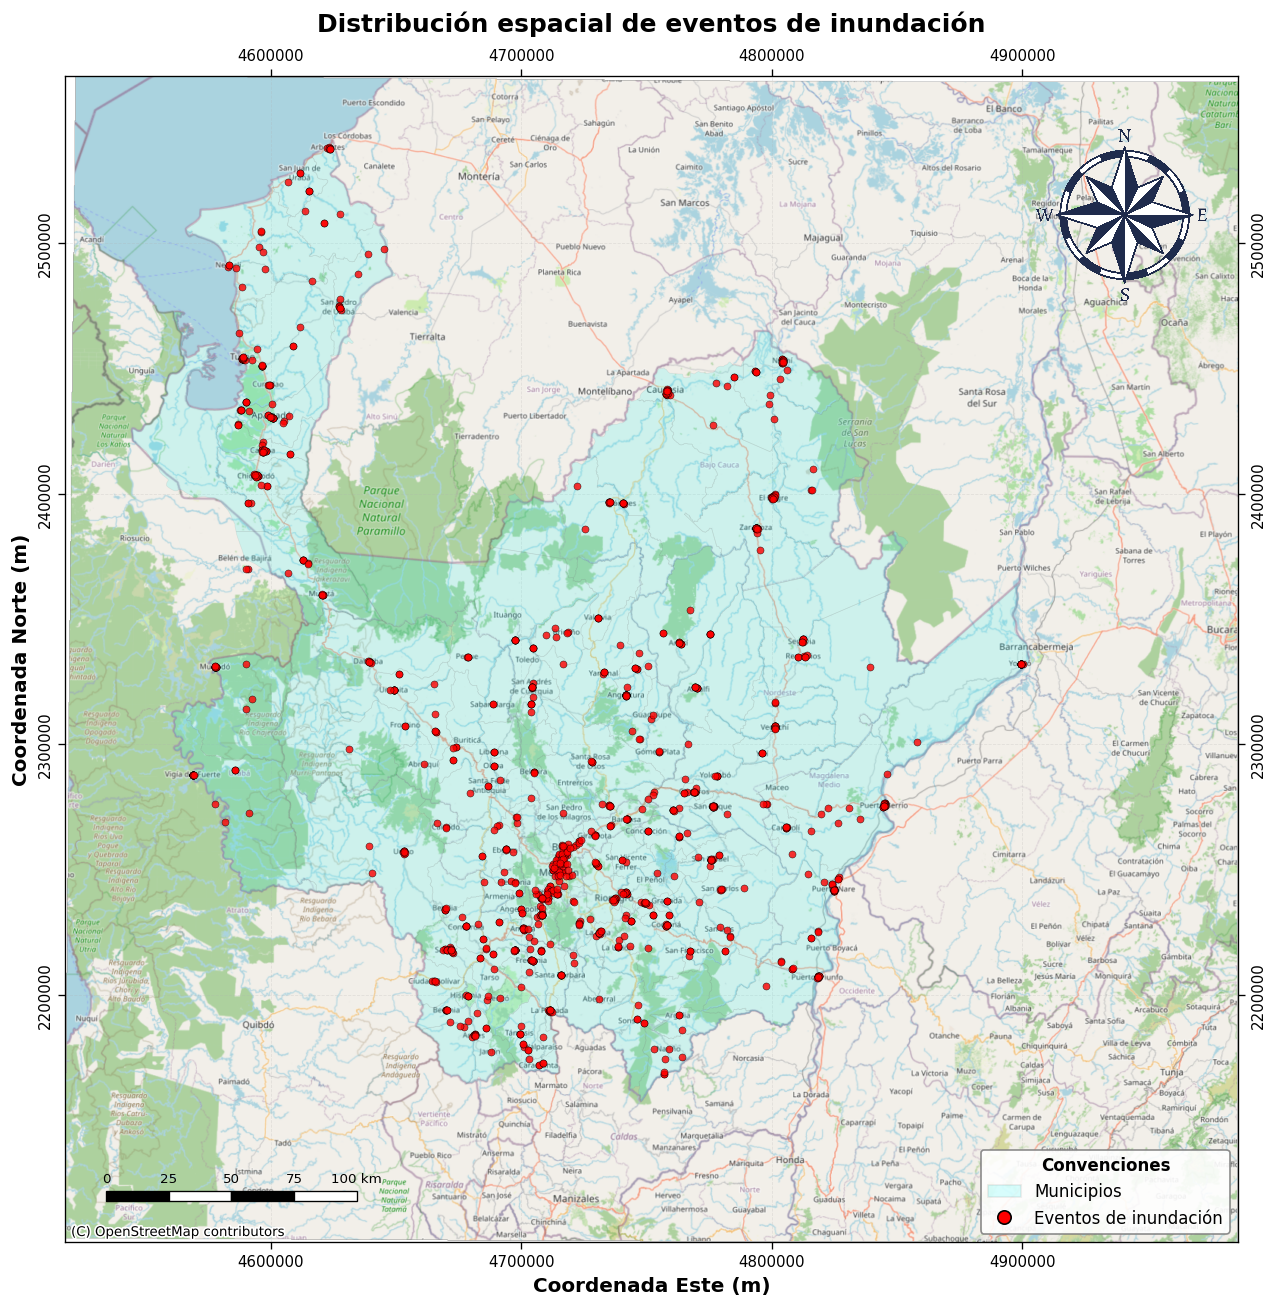

In [5]:
xmin, ymin, xmax, ymax = municipios.total_bounds
mx = (xmax - xmin) * 0.06
my = (ymax - ymin) * 0.04

fig, ax = plt.subplots(figsize=(11, 11), dpi=120)

municipios.plot(
    ax=ax,
    facecolor="cyan",
    edgecolor="gray",
    linewidth=0.4,
    alpha=0.15,
    zorder=2
)

gdf_proyectado.plot(
    ax=ax,
    color="red",
    markersize=18,
    edgecolor="black",
    linewidth=0.3,
    alpha=0.8,
    zorder=3
)

ax.set_xlim(xmin - mx, xmax + mx)
ax.set_ylim(ymin - my, ymax + my)

ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik,
    crs=municipios.crs,
    zoom=9,
    reset_extent=False,
    zorder=1
)

ax.set_xlabel("Coordenada Este (m)", fontsize=12, fontweight="bold")
ax.set_ylabel("Coordenada Norte (m)", fontsize=12, fontweight="bold")

ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.0f}"))
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.0f}"))

ax.tick_params(
    top=True, bottom=True, left=True, right=True,
    labeltop=True, labelbottom=True,
    labelleft=True, labelright=True,
    labelsize=9, direction="out", length=4
)

for tick in ax.get_yticklabels():
    tick.set_rotation(90)
    tick.set_va("center")

flecha = mpimg.imread(
    r"C:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\Mapas\Flecha_norte.png"
)

ax.add_artist(
    AnnotationBbox(
        OffsetImage(flecha, zoom=0.03),
        (0.90, 0.88),
        xycoords="axes fraction",
        frameon=False,
        zorder=10
    )
)

def barra_escala(ax, longitud=100000, segmentos=4):
    x0 = ax.get_xlim()[0] + 0.035 * np.ptp(ax.get_xlim())
    y0 = ax.get_ylim()[0] + 0.035 * np.ptp(ax.get_ylim())
    alto = 0.009 * np.ptp(ax.get_ylim())
    tramo = longitud / segmentos

    for i in range(segmentos):
        ax.add_patch(
            Rectangle(
                (x0 + i * tramo, y0),
                tramo, alto,
                facecolor="black" if i % 2 == 0 else "white",
                edgecolor="black",
                linewidth=0.8,
                zorder=10
            )
        )

        ax.text(
            x0 + i * tramo,
            y0 + alto * 1.5,
            f"{int(i * tramo / 1000)}",
            ha="center",
            va="bottom",
            fontsize=8,
            zorder=10
        )

    ax.text(
        x0 + longitud,
        y0 + alto * 1.5,
        f"{int(longitud / 1000)} km",
        ha="center",
        va="bottom",
        fontsize=8,
        zorder=10
    )

barra_escala(ax, longitud=100000, segmentos=4)

leg = ax.legend(
    handles=[
        Patch(
            facecolor="cyan",
            edgecolor="gray",
            alpha=0.15,
            label="Municipios"
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="none",
            markerfacecolor="red",
            markeredgecolor="black",
            markersize=8,
            label="Eventos de inundación"
        )
    ],
    title="Convenciones",
    loc="lower right",
    frameon=True,
    framealpha=0.9,
    facecolor="white",
    edgecolor="gray"
)

leg.get_title().set_fontweight("bold")

ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.25)
ax.set_title(
    "Distribución espacial de eventos de inundación",
    fontsize=15,
    fontweight="bold",
    pad=10
)

ax.set_aspect("equal")
plt.tight_layout()
plt.show()

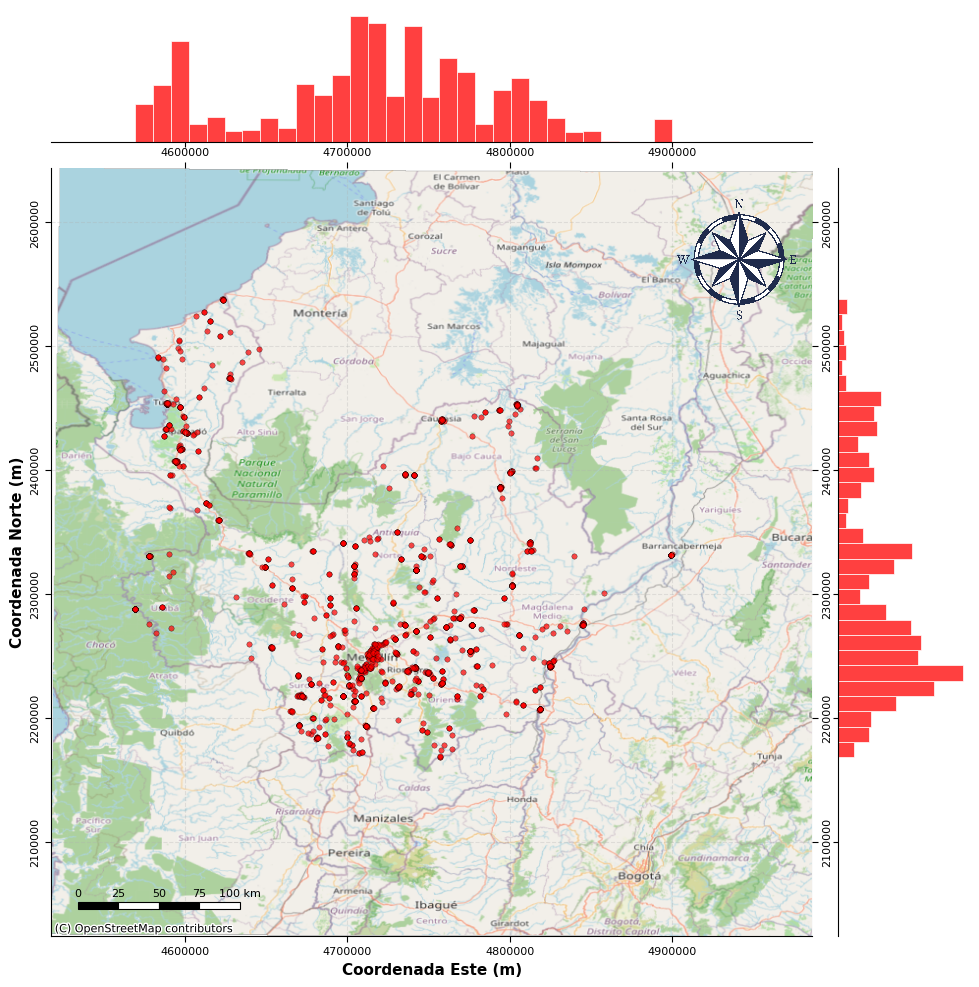

In [6]:
df_coords = pd.DataFrame({
    "Coordenada X (m)": gdf_proyectado.geometry.x,
    "Coordenada Y (m)": gdf_proyectado.geometry.y
})

g = sns.jointplot(
    x="Coordenada X (m)",
    y="Coordenada Y (m)",
    data=df_coords,
    kind="scatter",
    s=15,
    color="red",
    alpha=0.7,
    edgecolor="black",
    linewidth=0.3,
    height=10,
    marginal_kws=dict(
        bins=30,
        edgecolor="white",
        linewidth=0.5
    )
)

ctx.add_basemap(
    g.ax_joint,
    source=ctx.providers.OpenStreetMap.Mapnik,
    crs=gdf_proyectado.crs,
    zorder=0,
    reset_extent=False
)

g.ax_joint.set_title(
    "Distribución Espacial de Inundaciones DAGRAN",
    fontsize=14,
    fontweight="bold",
    pad=90
)

g.ax_joint.grid(
    True,
    linestyle="--",
    alpha=0.3
)

g.ax_joint.set_xlabel(
    "Coordenada Este (m)",
    fontsize=11,
    fontweight="bold"
)

g.ax_joint.set_ylabel(
    "Coordenada Norte (m)",
    fontsize=11,
    fontweight="bold"
)

g.ax_joint.xaxis.set_major_formatter(
    ticker.StrMethodFormatter("{x:.0f}")
)

g.ax_joint.yaxis.set_major_formatter(
    ticker.StrMethodFormatter("{x:.0f}")
)

g.ax_joint.tick_params(
    top=True,
    bottom=True,
    left=True,
    right=True,
    labeltop=True,
    labelbottom=True,
    labelleft=True,
    labelright=True,
    labelsize=8,
    direction="out",
    length=4
)

for tick in g.ax_joint.get_yticklabels():
    tick.set_rotation(90)
    tick.set_va("center")

flecha = mpimg.imread(
    r"C:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\Mapas\Flecha_norte.png"
)

g.ax_joint.add_artist(
    AnnotationBbox(
        OffsetImage(flecha, zoom=0.025),
        (0.90, 0.88),
        xycoords="axes fraction",
        frameon=False,
        zorder=10
    )
)

def barra_escala(ax, longitud=100000, segmentos=4):
    x0 = ax.get_xlim()[0] + 0.035 * np.ptp(ax.get_xlim())
    y0 = ax.get_ylim()[0] + 0.035 * np.ptp(ax.get_ylim())
    alto = 0.009 * np.ptp(ax.get_ylim())
    tramo = longitud / segmentos

    for i in range(segmentos):
        ax.add_patch(
            Rectangle(
                (x0 + i * tramo, y0),
                tramo,
                alto,
                facecolor="black" if i % 2 == 0 else "white",
                edgecolor="black",
                linewidth=0.8,
                zorder=10
            )
        )

        ax.text(
            x0 + i * tramo,
            y0 + alto * 1.5,
            f"{int(i * tramo / 1000)}",
            ha="center",
            va="bottom",
            fontsize=8,
            zorder=10
        )

    ax.text(
        x0 + longitud,
        y0 + alto * 1.5,
        f"{int(longitud / 1000)} km",
        ha="center",
        va="bottom",
        fontsize=8,
        zorder=10
    )

barra_escala(
    g.ax_joint,
    longitud=100000,
    segmentos=4
)

plt.show()

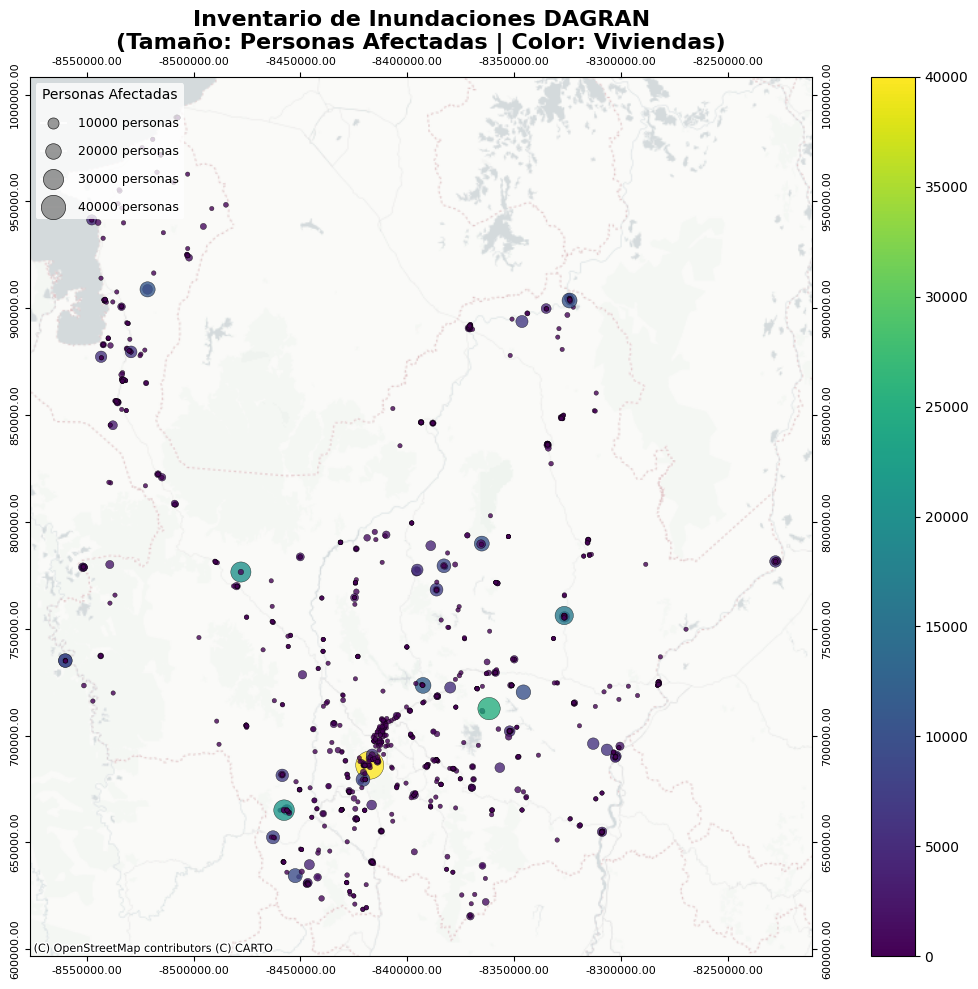

In [ ]:
tamanos = (gdf_proyectado['PERSONAS_A'] * 0.01) + 10
valores_referencia = [10000, 20000, 30000, 40000] 

tamanos_visuales_leyenda = [8, 11.2, 14.5, 17.5]

leyenda_tamanos = [
    Line2D([0], [0], marker='o', color='w', 
           label=f"{v} personas",
           markerfacecolor='gray', 
           markersize=tam_vis, # <-- Tamaño controlado para que quepa en el recuadro
           markeredgecolor='black', markeredgewidth=0.5, alpha=0.8)
    for v, tam_vis in zip(valores_referencia, tamanos_visuales_leyenda)
]

# --- Configuración de la Figura y el Mapa ---
fig, ax = plt.subplots(figsize=(12, 10))

# Graficar el mapa con la barra de color (VIVIENDASD)
gdf_proyectado.plot(
    ax=ax, 
    column='Area', 
    markersize=tamanos, # Mantiene tu escala original en el mapa
    alpha=0.8,
    edgecolor='black',
    linewidth=0.3,
    legend=True,
    zorder=2
)

# Añadir la leyenda de tamaños corregida
ax.legend(
    handles=leyenda_tamanos, 
    title="Personas Afectadas", 
    loc="upper left",          
    frameon=True,              
    facecolor='white',         
    edgecolor='none', 
    fontsize=9, 
    title_fontsize=10,
    labelspacing=1.2, # Añade un espacio cómodo entre cada fila de la leyenda
    handletextpad=1.0
)

# Agregar el mapa base de CartoDB
ctx.add_basemap(
    ax, 
    source=ctx.providers.CartoDB.PositronNoLabels, 
    zorder=1
)

ax.set_title('Inventario de Inundaciones DAGRAN\n(Tamaño: Personas Afectadas | Color: Viviendas)', fontsize=16, fontweight='bold', pad=20)

ax.tick_params(
    axis='both', 
    which='both', 
    bottom=True, top=True, left=True, right=True, 
    labelbottom=True, labeltop=True, labelleft=True, labelright=True, 
    labelsize=8
)

ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

for tick in ax.get_yticklabels():
    tick.set_rotation(90)
    tick.set_verticalalignment('center')

plt.tight_layout()
plt.show()

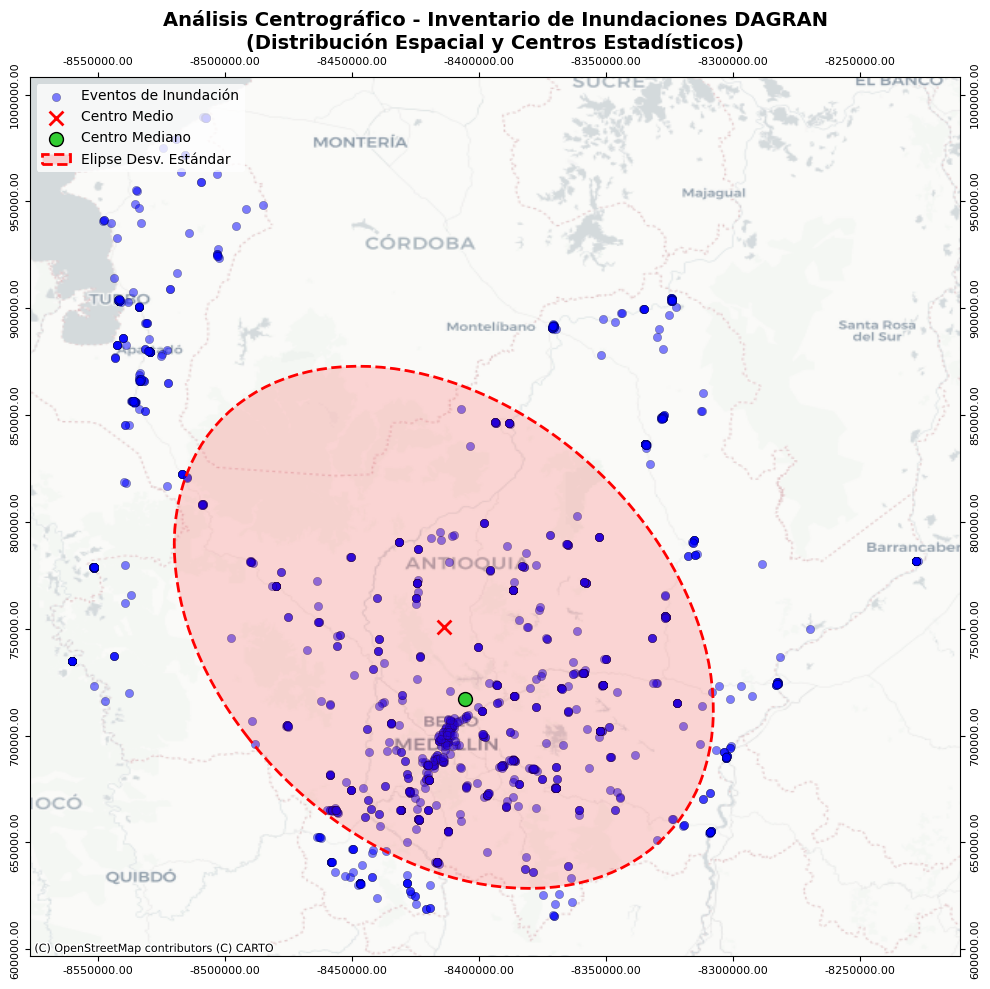

In [ ]:
coordenadas_xy = np.column_stack((gdf_proyectado.geometry.x, gdf_proyectado.geometry.y))
mean_center = centrography.mean_center(coordenadas_xy)
med_center = centrography.euclidean_median(coordenadas_xy)

major, minor, rotation = centrography.ellipse(coordenadas_xy)

fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(gdf_proyectado.geometry.x, gdf_proyectado.geometry.y, color='blue', alpha=0.5, edgecolor='black', linewidth=0.3, label='Eventos de Inundación', zorder=2)

# Graficar el Centro Medio y Centro Mediano
ax.scatter(mean_center[0], mean_center[1], color='red', marker='x', s=100, linewidth=2, label='Centro Medio', zorder=4)
ax.scatter(med_center[0], med_center[1], color='limegreen', marker='o', s=100, edgecolor='black', label='Centro Mediano', zorder=4)


ellipse = Ellipse(
    xy=mean_center, 
    width=major * 2, 
    height=minor * 2, 
    angle=np.rad2deg(rotation), 
    facecolor=(1, 0, 0, 0.15),  # <-- Rojo claro translúcido (RGBA: 15% de opacidad)
    edgecolor='red', 
    linestyle='--', 
    linewidth=2,
    label='Elipse Desv. Estándar', 
    zorder=3
)
ax.add_patch(ellipse)

# Agregar mapa base
ctx.add_basemap(
    ax, 
    source=ctx.providers.CartoDB.Positron, 
    zorder=1
)

# --- 4. Formato Estético de Ejes (Consistente con tus mapas anteriores) ---
ax.set_title('Análisis Centrográfico - Inventario de Inundaciones DAGRAN\n(Distribución Espacial y Centros Estadísticos)', 
             fontsize=14, fontweight='bold', pad=20)

ax.legend(loc="upper left", frameon=True, facecolor='white', edgecolor='none')

ax.tick_params(
    axis='both', 
    which='both', 
    bottom=True, top=True, left=True, right=True, 
    labelbottom=True, labeltop=True, labelleft=True, labelright=True, 
    labelsize=8
)

ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

for tick in ax.get_yticklabels():
    tick.set_rotation(90)
    tick.set_verticalalignment('center')

plt.tight_layout()
plt.show()

Factor de bandwidth Silverman: 0.3039


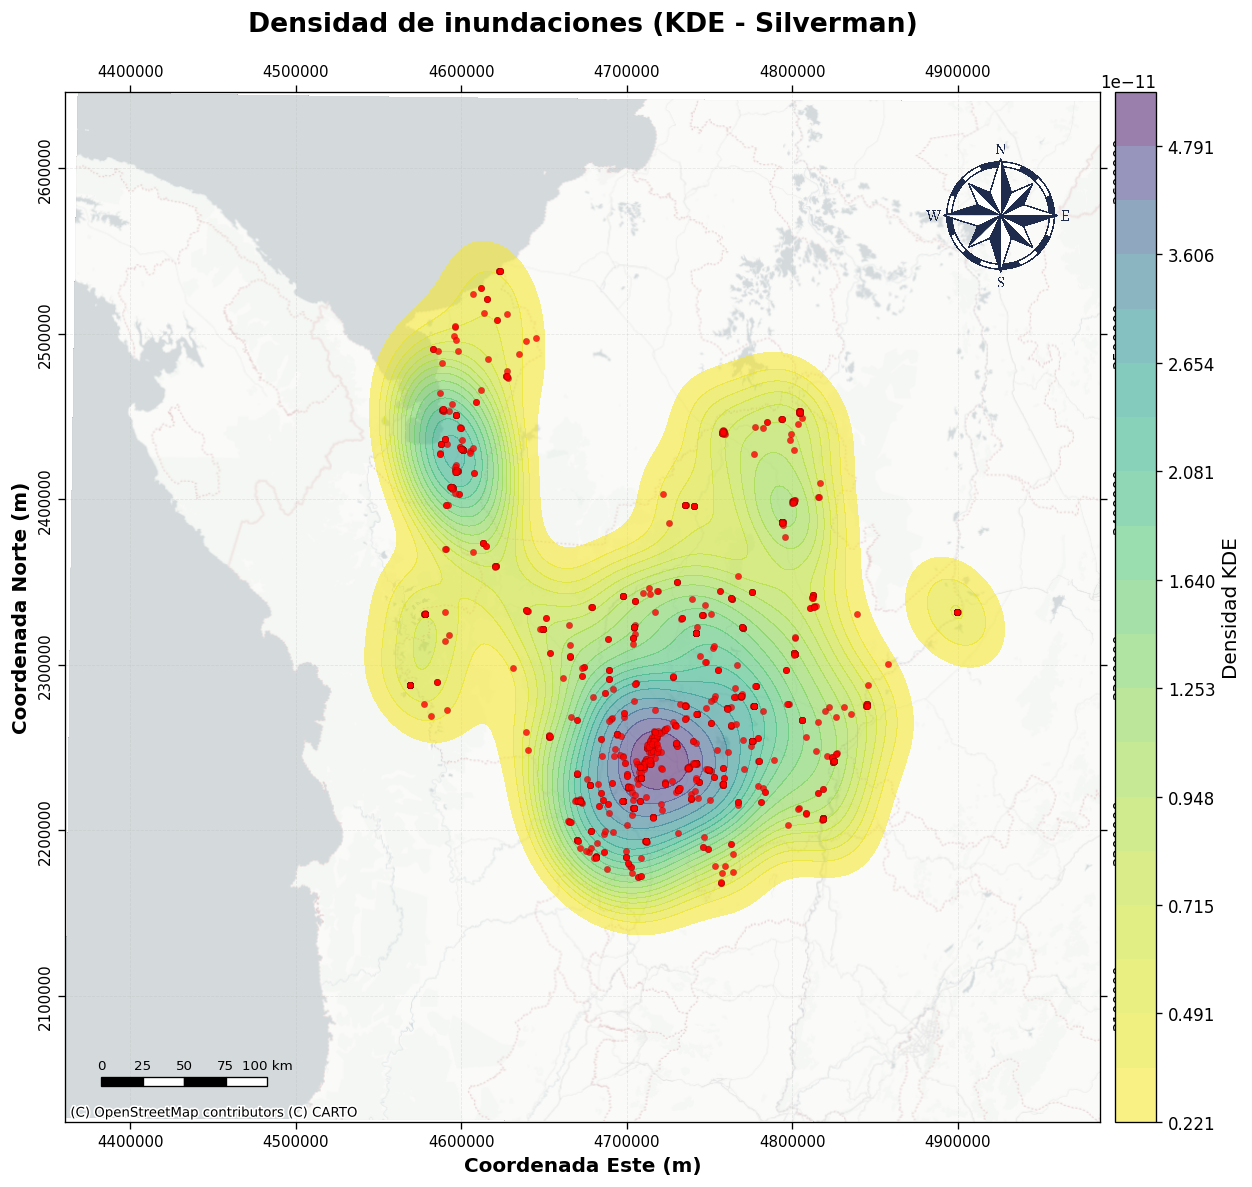

In [15]:
gdf_proyectado = gdf.to_crs(9377)

x = gdf_proyectado.geometry.x
y = gdf_proyectado.geometry.y

data = np.vstack([x, y])
kde_scipy = gaussian_kde(data, bw_method="silverman")

print(
    f"Factor de bandwidth Silverman: "
    f"{kde_scipy.covariance_factor():.4f}"
)

fig, ax = plt.subplots(figsize=(12, 10), dpi=120)

kde = sns.kdeplot(
    x=x,
    y=y,
    ax=ax,
    cmap="viridis_r",
    levels=20,
    bw_method="silverman",
    fill=True,
    alpha=0.55,
    zorder=2
)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.12)

cbar = plt.colorbar(kde.collections[-1], cax=cax)
cbar.set_label("Densidad KDE", fontsize=12)
cbar.ax.tick_params(labelsize=10)

gdf_proyectado.plot(
    ax=ax,
    markersize=15,
    color="red",
    edgecolor="black",
    linewidth=0.1,
    alpha=0.8,
    zorder=3
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.PositronNoLabels,
    crs=gdf_proyectado.crs,
    reset_extent=False,
    zorder=1
)

ax.set_title(
    "Densidad de inundaciones (KDE - Silverman)",
    fontsize=16,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("Coordenada Este (m)", fontsize=12, fontweight="bold")
ax.set_ylabel("Coordenada Norte (m)", fontsize=12, fontweight="bold")

ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.0f}"))
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.0f}"))

ax.tick_params(
    top=True, bottom=True, left=True, right=True,
    labeltop=True, labelbottom=True,
    labelleft=True, labelright=True,
    labelsize=9, direction="out", length=4
)

for tick in ax.get_yticklabels():
    tick.set_rotation(90)
    tick.set_va("center")

flecha = mpimg.imread(
    r"C:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial"
    r"\Mapas\Flecha_norte.png"
)

ax.add_artist(
    AnnotationBbox(
        OffsetImage(flecha, zoom=0.025),
        (0.90, 0.88),
        xycoords="axes fraction",
        frameon=False,
        zorder=10
    )
)

def barra_escala(ax, longitud=100000, segmentos=4):
    x0 = ax.get_xlim()[0] + 0.035 * np.ptp(ax.get_xlim())
    y0 = ax.get_ylim()[0] + 0.035 * np.ptp(ax.get_ylim())
    alto = 0.009 * np.ptp(ax.get_ylim())
    tramo = longitud / segmentos

    for i in range(segmentos):
        ax.add_patch(
            Rectangle(
                (x0 + i * tramo, y0),
                tramo,
                alto,
                facecolor="black" if i % 2 == 0 else "white",
                edgecolor="black",
                linewidth=0.8,
                zorder=10
            )
        )

        ax.text(
            x0 + i * tramo,
            y0 + alto * 1.5,
            f"{int(i * tramo / 1000)}",
            ha="center",
            va="bottom",
            fontsize=8,
            zorder=10
        )

    ax.text(
        x0 + longitud,
        y0 + alto * 1.5,
        f"{int(longitud / 1000)} km",
        ha="center",
        va="bottom",
        fontsize=8,
        zorder=10
    )

barra_escala(ax, longitud=100000, segmentos=4)

ax.grid(
    True,
    linestyle="--",
    linewidth=0.5,
    alpha=0.25
)

plt.tight_layout()
plt.show()

Lado de celda Silverman: 24245.94 m
Área aproximada de celda: 587.87 km²


C:\Users\juand\AppData\Local\Temp\ipykernel_25028\4172603928.py:270: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.93])


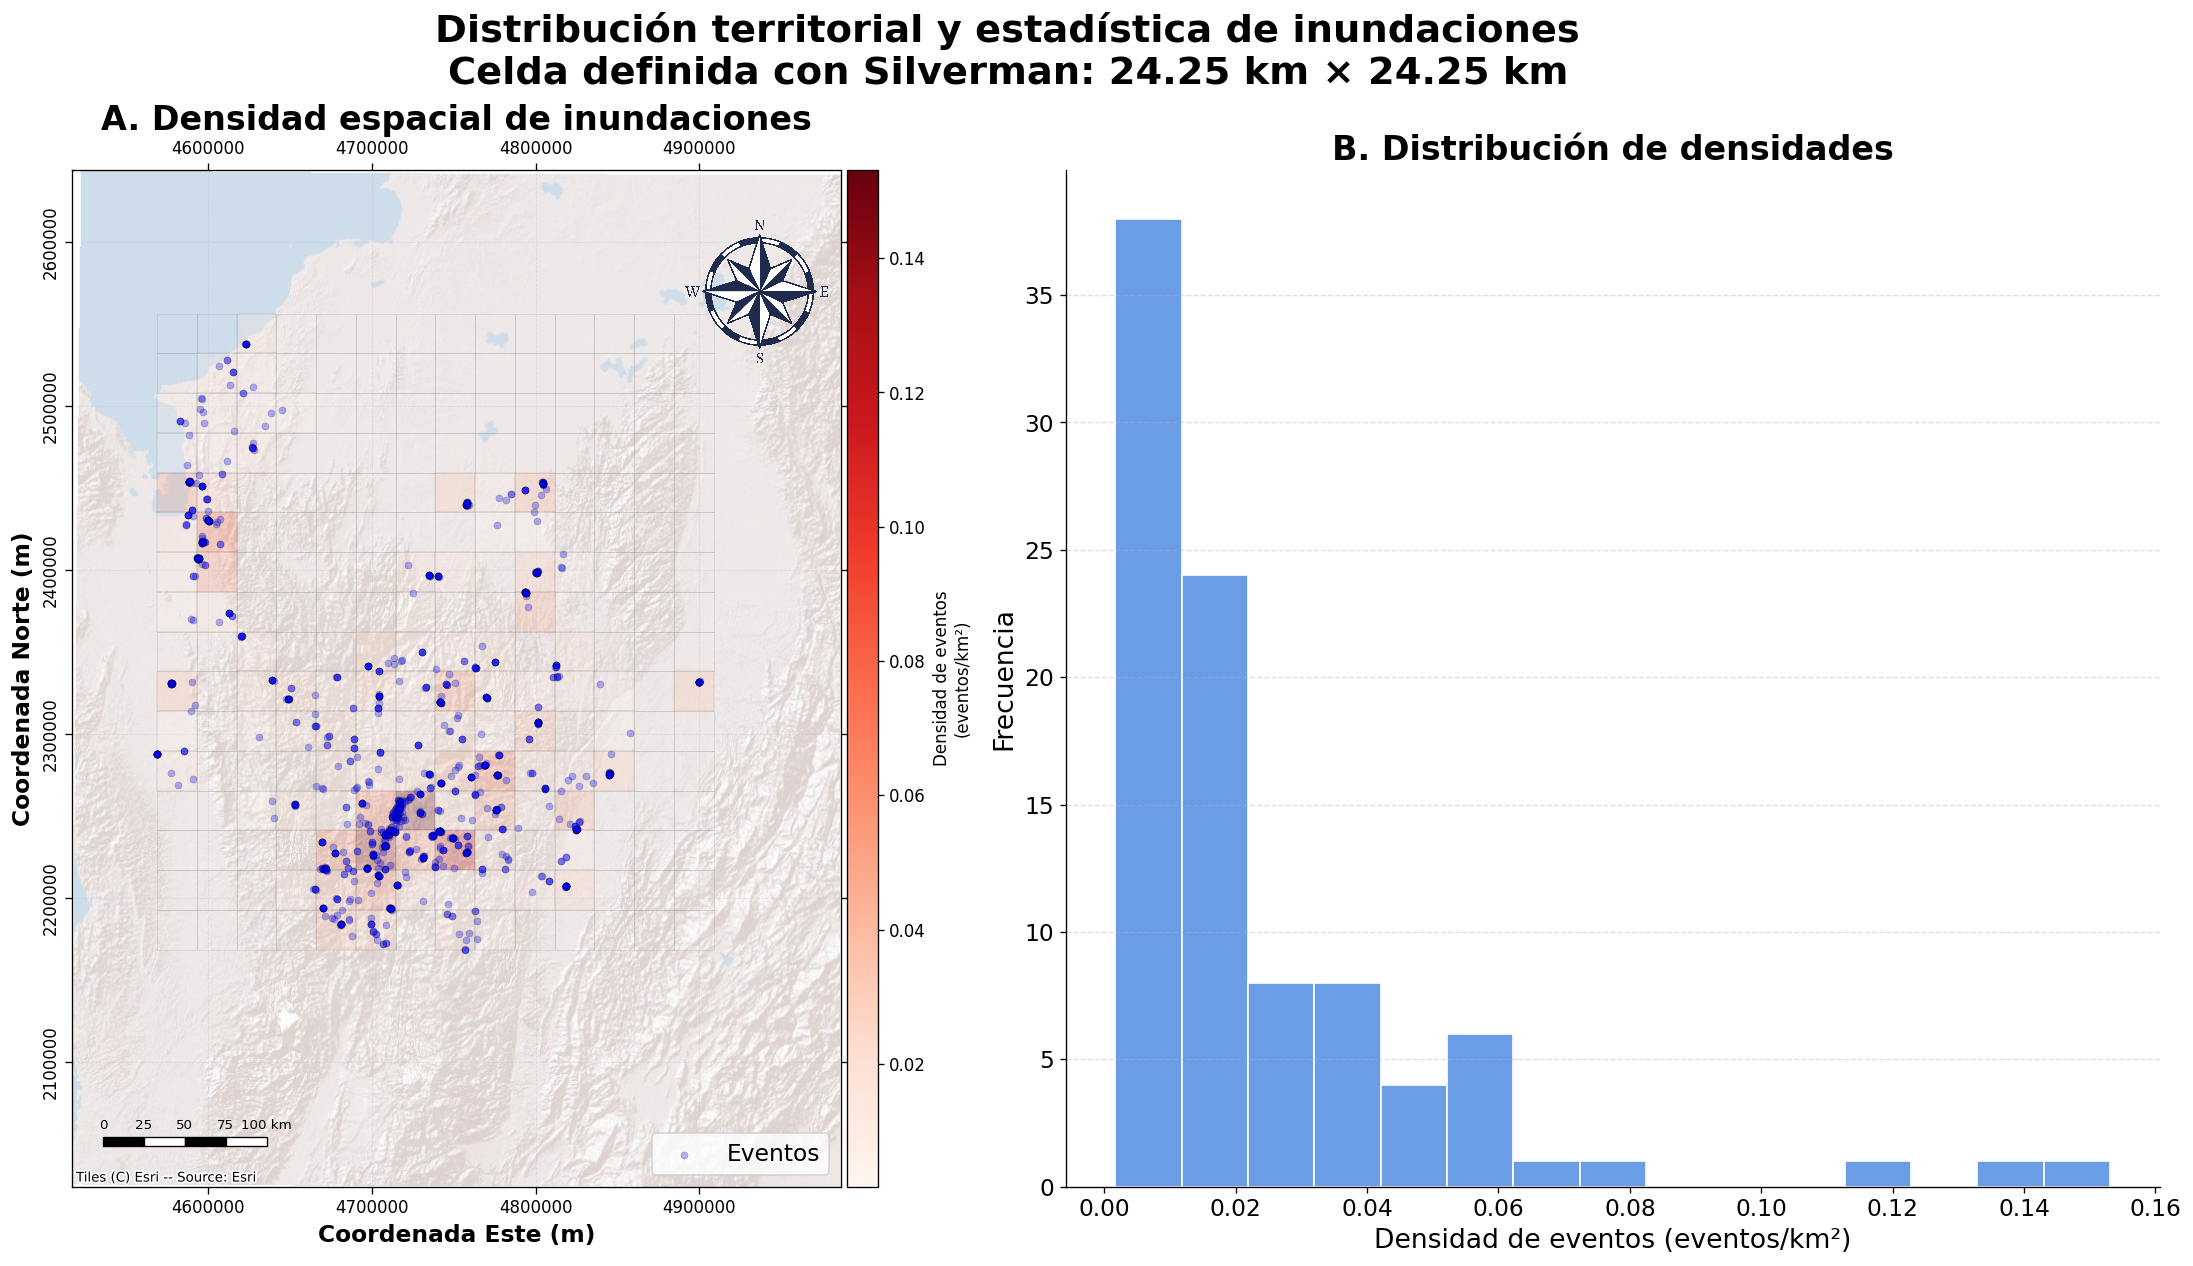

In [20]:
gdf_proyectado = gdf.to_crs(9377)

x = gdf_proyectado.geometry.x.values
y = gdf_proyectado.geometry.y.values
n = len(gdf_proyectado)

sigma = np.mean([np.std(x), np.std(y)])
lado_celda = sigma * n ** (-1 / 6)
tamano_celda_km2 = lado_celda**2 / 1_000_000

print(f"Lado de celda Silverman: {lado_celda:.2f} m")
print(f"Área aproximada de celda: {tamano_celda_km2:.2f} km²")

xmin, ymin, xmax, ymax = gdf_proyectado.total_bounds

xs = np.arange(xmin, xmax + lado_celda, lado_celda)
ys = np.arange(ymin, ymax + lado_celda, lado_celda)

grid = gpd.GeoDataFrame(
    geometry=[
        box(x1, y1, x1 + lado_celda, y1 + lado_celda)
        for x1 in xs[:-1]
        for y1 in ys[:-1]
    ],
    crs=gdf_proyectado.crs
)

join = gpd.sjoin(
    gdf_proyectado,
    grid,
    how="inner",
    predicate="within"
)

conteos = join.groupby("index_right").size()

grid["conteo"] = grid.index.map(conteos).fillna(0).astype(int)
grid["densidad_km2"] = grid["conteo"] / (grid.area / 1_000_000)

grid_datos = grid[grid["conteo"] > 0]
grid_vacio = grid[grid["conteo"] == 0]

fig, (ax_mapa, ax_histo) = plt.subplots(
    1, 2,
    figsize=(24, 11),
    dpi=120,
    gridspec_kw={
        "width_ratios": [1, 1],
        "wspace": 0.04
    }
)

grid_vacio.plot(
    ax=ax_mapa,
    facecolor="none",
    edgecolor="gray",
    linewidth=0.3,
    alpha=0.35,
    zorder=2
)

divider = make_axes_locatable(ax_mapa)
cax = divider.append_axes("right", size="4%", pad=0.05)

grid_datos.plot(
    ax=ax_mapa,
    column="densidad_km2",
    cmap="Reds",
    edgecolor="black",
    linewidth=0.25,
    alpha=0.25,
    legend=True,
    cax=cax,
    legend_kwds={
        "label": "Densidad de eventos\n(eventos/km²)"
    },
    zorder=3
)

gdf_proyectado.plot(
    ax=ax_mapa,
    color="blue",
    markersize=18,
    alpha=0.3,
    edgecolor="black",
    linewidth=0.3,
    label="Eventos",
    zorder=4
)

ax_mapa.set_xlim(xmin - lado_celda, xmax + lado_celda)
ax_mapa.set_ylim(ymin - lado_celda, ymax + lado_celda)

ctx.add_basemap(
    ax_mapa,
    source=ctx.providers.Esri.WorldShadedRelief,
    crs=gdf_proyectado.crs,
    zoom="auto",
    reset_extent=False,
    alpha=0.5,
    zorder=0
)

ax_mapa.set_title(
    "A. Densidad espacial de inundaciones",
    fontsize=20,
    fontweight="bold"
)

ax_mapa.set_xlabel(
    "Coordenada Este (m)",
    fontsize=14,
    fontweight="bold"
)

ax_mapa.set_ylabel(
    "Coordenada Norte (m)",
    fontsize=14,
    fontweight="bold"
)

ax_mapa.xaxis.set_major_formatter(
    ticker.StrMethodFormatter("{x:.0f}")
)

ax_mapa.yaxis.set_major_formatter(
    ticker.StrMethodFormatter("{x:.0f}")
)

ax_mapa.tick_params(
    top=True,
    bottom=True,
    left=True,
    right=True,
    labeltop=True,
    labelbottom=True,
    labelleft=True,
    labelright=True,
    labelsize=10,
    direction="out",
    length=4
)

for tick in ax_mapa.get_yticklabels():
    tick.set_rotation(90)
    tick.set_va("center")

flecha = mpimg.imread(
    r"C:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial"
    r"\Mapas\Flecha_norte.png"
)

ax_mapa.add_artist(
    AnnotationBbox(
        OffsetImage(flecha, zoom=0.025),
        (0.89, 0.88),
        xycoords="axes fraction",
        frameon=False,
        zorder=10
    )
)

def barra_escala(ax, longitud=100000, segmentos=4):
    ancho = np.ptp(ax.get_xlim())
    alto_mapa = np.ptp(ax.get_ylim())

    x0 = ax.get_xlim()[0] + 0.04 * ancho
    y0 = ax.get_ylim()[0] + 0.04 * alto_mapa
    alto = 0.009 * alto_mapa
    tramo = longitud / segmentos

    for i in range(segmentos):
        ax.add_patch(
            Rectangle(
                (x0 + i * tramo, y0),
                tramo,
                alto,
                facecolor="black" if i % 2 == 0 else "white",
                edgecolor="black",
                linewidth=0.8,
                zorder=10
            )
        )

        ax.text(
            x0 + i * tramo,
            y0 + alto * 1.5,
            f"{int(i * tramo / 1000)}",
            ha="center",
            va="bottom",
            fontsize=8,
            zorder=10
        )

    ax.text(
        x0 + longitud,
        y0 + alto * 1.5,
        f"{int(longitud / 1000)} km",
        ha="center",
        va="bottom",
        fontsize=8,
        zorder=10
    )

barra_escala(
    ax_mapa,
    longitud=100000,
    segmentos=4
)

ax_mapa.legend(
    loc="lower right",
    fontsize=14,
    frameon=True
)

ax_mapa.grid(
    linestyle="--",
    linewidth=0.5,
    alpha=0.25
)

sns.histplot(
    grid_datos["densidad_km2"],
    bins=15,
    color="#4585DF",
    edgecolor="white",
    alpha=0.8,
    ax=ax_histo
)

ax_histo.set_title(
    "B. Distribución de densidades",
    fontsize=20,
    fontweight="bold"
)

ax_histo.set_xlabel(
    "Densidad de eventos (eventos/km²)",
    fontsize=16
)

ax_histo.set_ylabel(
    "Frecuencia",
    fontsize=16
)

ax_histo.tick_params(
    axis="both",
    labelsize=14
)

ax_histo.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

sns.despine(ax=ax_histo)

plt.suptitle(
    "Distribución territorial y estadística de inundaciones\n"
    f"Celda definida con Silverman: "
    f"{lado_celda / 1000:.2f} km × {lado_celda / 1000:.2f} km",
    fontsize=23,
    fontweight="bold",
    y=1
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [ ]:
grid.describe()

,conteo,densidad_km2
count,224.000000,224.000000
mean,5.602679,0.009327
std,12.142214,0.020213
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,7.000000,0.011653
max,86.000000,0.143163


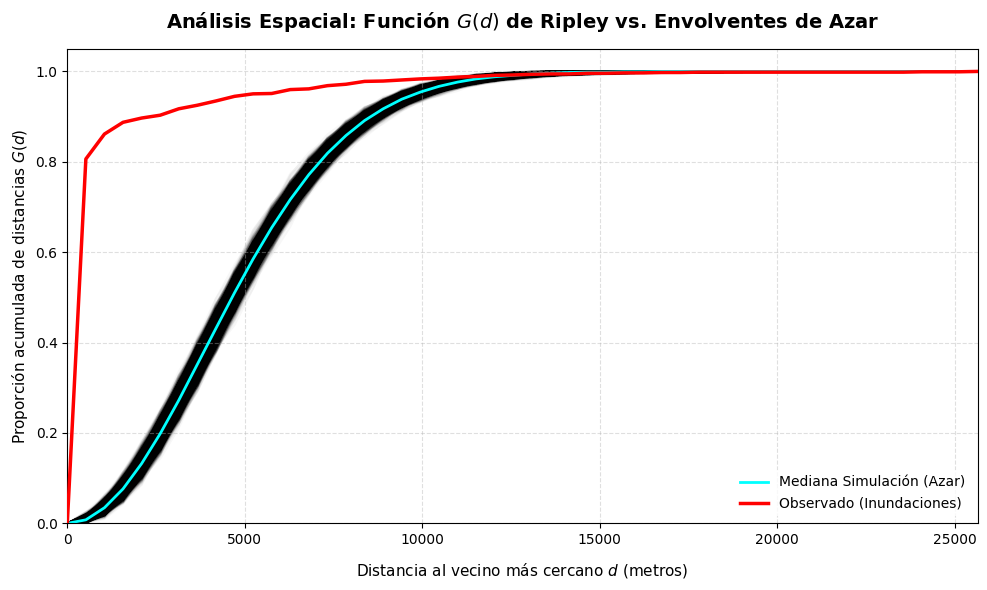

In [ ]:
gdf_ON = gdf.to_crs(epsg=9377)

coordenadas = np.column_stack((gdf_ON.geometry.x, gdf_ON.geometry.y))
g_test = distance_statistics.g_test(coordenadas, support=50, keep_simulations=True)

fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

ax.plot(g_test.support, g_test.simulations.T, color='k', alpha=0.03, zorder=1)

ax.plot(g_test.support, np.median(g_test.simulations, axis=0), 
        color='cyan', linewidth=2, label='Mediana Simulación (Azar)', zorder=2)

ax.plot(g_test.support, g_test.statistic, 
        color='red', linewidth=2.5, label='Observado (Inundaciones)', zorder=3)

ax.set_title("Análisis Espacial: Función $G(d)$ de Ripley vs. Envolventes de Azar", 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Distancia al vecino más cercano $d$ (metros)', fontsize=11, labelpad=10)
ax.set_ylabel('Proporción acumulada de distancias $G(d)$', fontsize=11)

ax.set_xlim(0, g_test.support.max())
ax.set_ylim(0, 1.05)

# Detalles finales de la grilla y leyenda
ax.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.legend(loc='lower right', fontsize=10, frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()

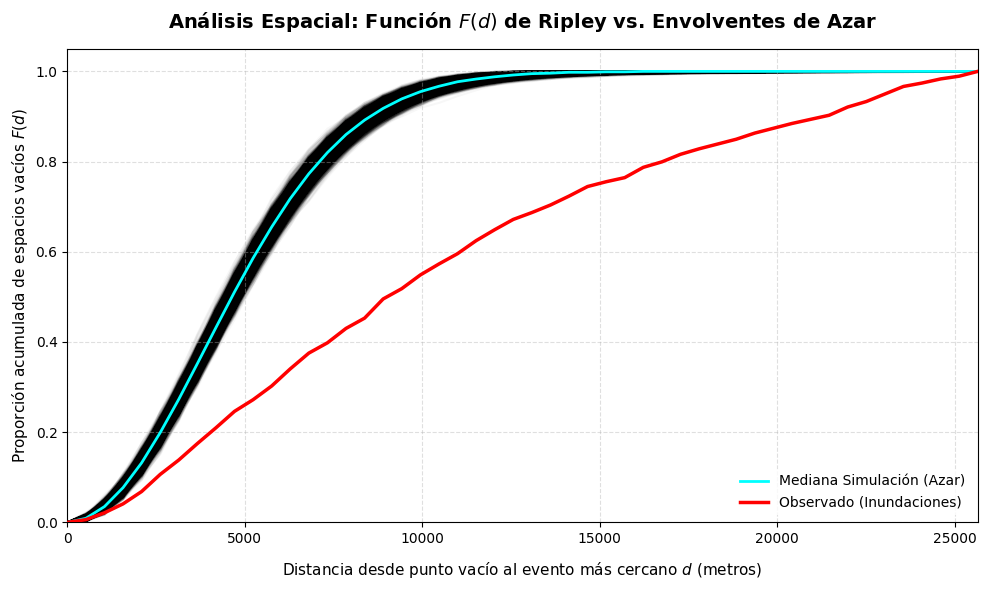

In [ ]:
f_test = distance_statistics.f_test(coordenadas, support=50, keep_simulations=True)

fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

# Graficar las líneas de las simulaciones aleatorias (Envolventes de fondo CSR)
ax.plot(f_test.support, f_test.simulations.T, color='k', alpha=0.03, zorder=1)

# Mostrar la mediana de las simulaciones aleatorias (Patrón esperado por azar)
ax.plot(f_test.support, np.median(f_test.simulations, axis=0), 
        color='cyan', linewidth=2, label='Mediana Simulación (Azar)', zorder=2)

# Graficar la curva empírica observada (Datos reales de inundación DAGRAN)
ax.plot(f_test.support, f_test.statistic, 
        color='red', linewidth=2.5, label='Observado (Inundaciones)', zorder=3)

ax.set_title("Análisis Espacial: Función $F(d)$ de Ripley vs. Envolventes de Azar", 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Distancia desde punto vacío al evento más cercano $d$ (metros)', fontsize=11, labelpad=10)
ax.set_ylabel('Proporción acumulada de espacios vacíos $F(d)$', fontsize=11)

# Forzar los límites dinámicos en metros para tus datos
ax.set_xlim(0, f_test.support.max())
ax.set_ylim(0, 1.05)

# Detalles finales de la grilla y leyenda
ax.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.legend(loc='lower right', fontsize=10, frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()

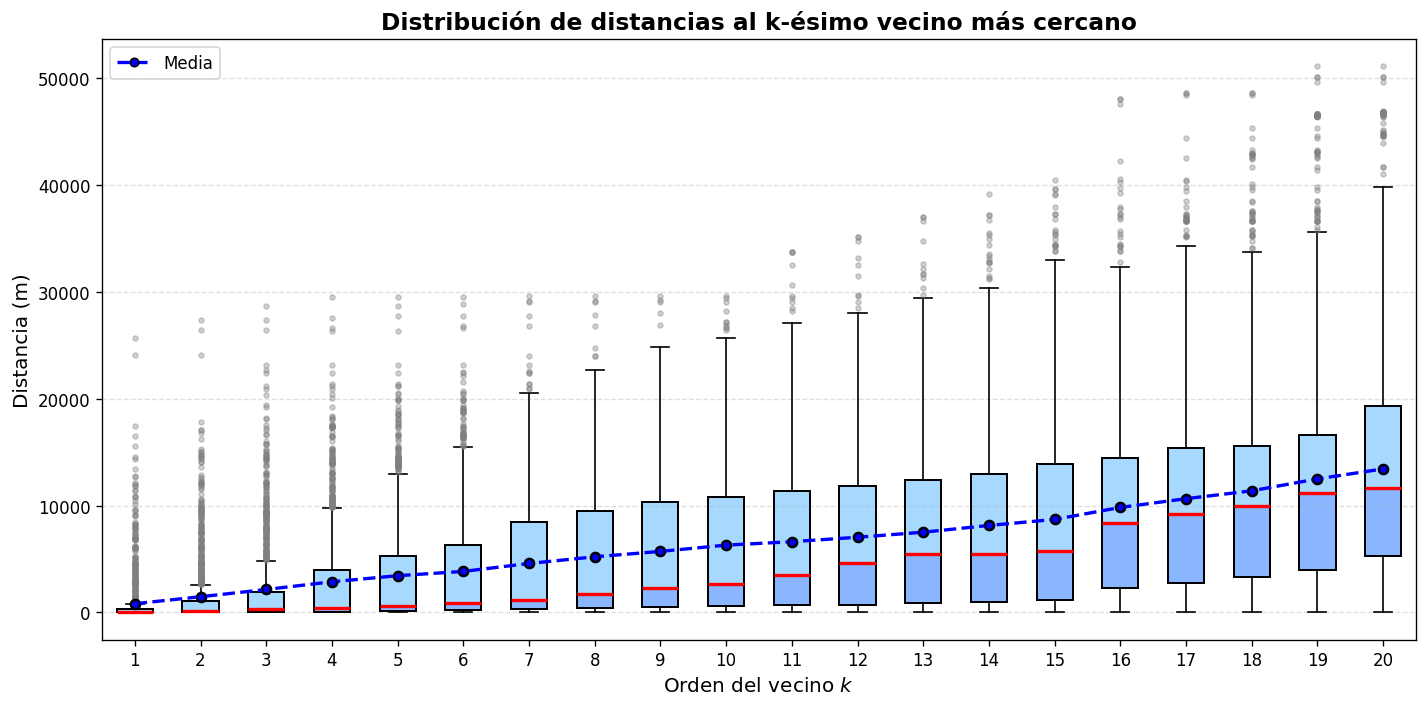

     k     Media   Mediana  Separacion  Desv.Est.       Q1        Q3  \
0    1    810.76      0.00      810.76    2338.55     0.00    316.71   
1    2   1462.10    162.64     1299.46    3135.55     0.00   1037.46   
2    3   2142.75    341.71     1801.04    4003.08     0.00   1934.18   
3    4   2861.41    435.04     2426.37    4648.23     2.50   3929.74   
4    5   3431.57    593.03     2838.54    5089.25   125.68   5244.70   
5    6   3832.46    843.37     2989.09    5384.86   243.78   6346.52   
6    7   4575.74   1134.31     3441.43    5778.54   321.82   8459.27   
7    8   5199.69   1680.14     3519.55    6031.27   381.10   9481.88   
8    9   5706.50   2288.80     3417.69    6253.12   540.64  10352.45   
9   10   6294.11   2699.44     3594.67    6746.96   610.15  10787.11   
10  11   6613.81   3519.57     3094.24    7039.71   651.55  11324.00   
11  12   7031.35   4577.43     2453.92    7271.55   731.86  11830.32   
12  13   7502.53   5475.15     2027.38    7470.45   893.86  1234

In [ ]:
from scipy.spatial.distance import cdist
from matplotlib.patches import Rectangle
import numpy as np
import matplotlib.pyplot as plt

matriz_distancias = cdist(coordenadas, coordenadas)
distancias_ordenadas = np.sort(matriz_distancias, axis=1)

max_k = 20
valores_k = np.arange(1, max_k + 1)

datos_boxplot = [
    distancias_ordenadas[:, k]
    for k in valores_k
]

fig, ax = plt.subplots(figsize=(12, 6), dpi=120)

bp = ax.boxplot(
    datos_boxplot,
    positions=valores_k,
    widths=0.55,
    patch_artist=True,
    showmeans=True,
    meanline=False,
    showfliers=True,

    boxprops=dict(
        facecolor="none",
        edgecolor="black",
        linewidth=1.2
    ),

    medianprops=dict(
        color="red",
        linewidth=2
    ),

    meanprops=dict(
        marker="o",
        markerfacecolor="blue",
        markeredgecolor="black",
        markersize=6
    ),

    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),

    flierprops=dict(
        marker="o",
        markersize=3,
        markerfacecolor="gray",
        markeredgecolor="gray",
        alpha=0.35
    )
)

color_inf = "#146EFF"
color_sup = "#51B4FF"

for box, med in zip(bp["boxes"], bp["medians"]):
    verts = box.get_path().vertices

    x0 = verts[:, 0].min()
    x1 = verts[:, 0].max()
    y0 = verts[:, 1].min()
    y1 = verts[:, 1].max()
    ymed = med.get_ydata()[0]

    ax.add_patch(
        Rectangle(
            (x0, y0),
            x1 - x0,
            ymed - y0,
            facecolor=color_inf,
            edgecolor="none",
            alpha=0.5,
            zorder=0
        )
    )

    ax.add_patch(
        Rectangle(
            (x0, ymed),
            x1 - x0,
            y1 - ymed,
            facecolor=color_sup,
            edgecolor="none",
            alpha=0.5,
            zorder=0
        )
    )

# ==========================================
# Unir las medias con una línea punteada azul
# ==========================================
medias = [
    mean.get_ydata()[0]
    for mean in bp["means"]
]

ax.plot(
    valores_k,
    medias,
    linestyle="--",
    linewidth=2,
    color="blue",
    marker="o",
    markersize=5,
    markerfacecolor="blue",
    markeredgecolor="black",
    zorder=5,
    label="Media"
)

ax.legend(loc="upper left")

ax.set_title(
    "Distribución de distancias al k-ésimo vecino más cercano",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Orden del vecino $k$", fontsize=12)
ax.set_ylabel("Distancia (m)", fontsize=12)

ax.set_xticks(valores_k)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

import pandas as pd
import numpy as np

resumen = pd.DataFrame({
    "k": valores_k,
    "Media": [np.mean(distancias_ordenadas[:, k]) for k in valores_k],
    "Mediana": [np.median(distancias_ordenadas[:, k]) for k in valores_k],
    "Separacion": [np.mean(distancias_ordenadas[:, k])-np.median(distancias_ordenadas[:, k]) for k in valores_k],
    "Desv.Est.": [np.std(distancias_ordenadas[:, k], ddof=1) for k in valores_k],
    "Mínimo": [np.min(distancias_ordenadas[:, k]) for k in valores_k],
    "Q1": [np.percentile(distancias_ordenadas[:, k], 25) for k in valores_k],
    "Q3": [np.percentile(distancias_ordenadas[:, k], 75) for k in valores_k],
    "Máximo": [np.max(distancias_ordenadas[:, k]) for k in valores_k],
})

resumen["RIC"] = resumen["Q3"] - resumen["Q1"]

resumen = resumen[
    ["k", "Media", "Mediana", "Separacion", "Desv.Est.", "Q1", "Q3", "RIC", "Mínimo", "Máximo"]
].round(2)

print(resumen)

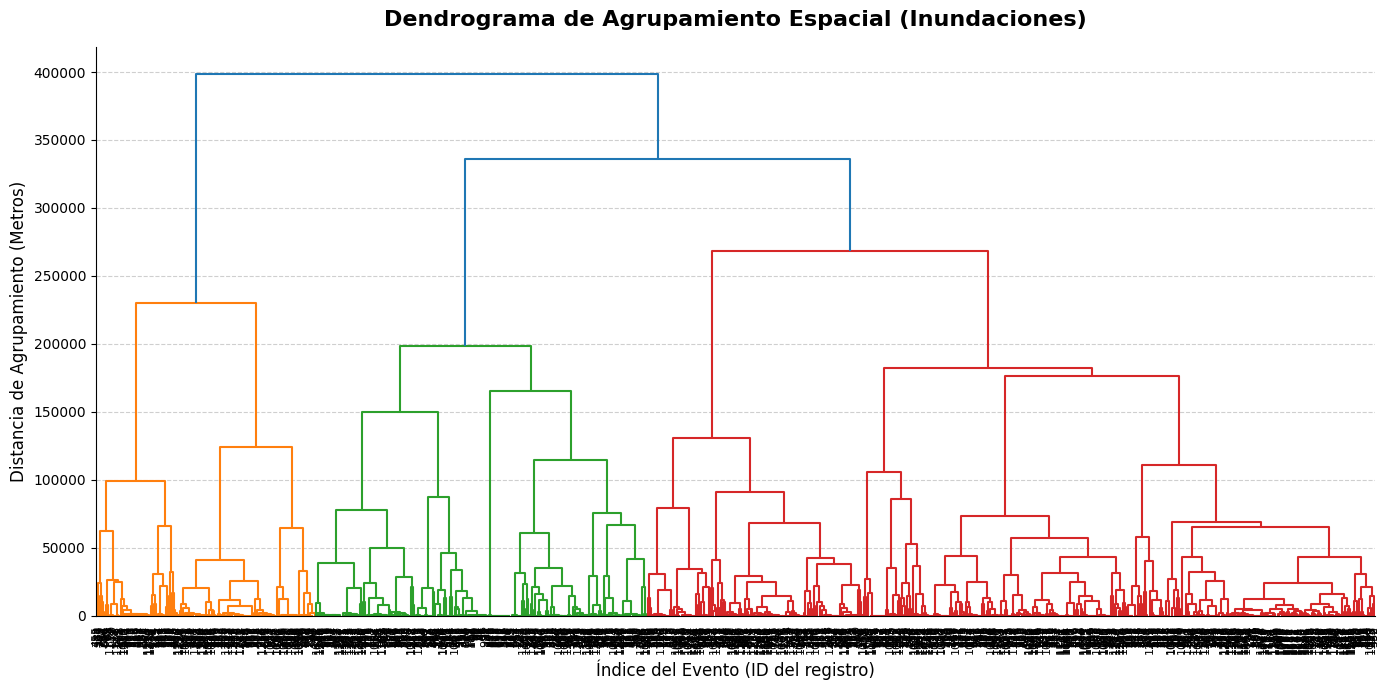

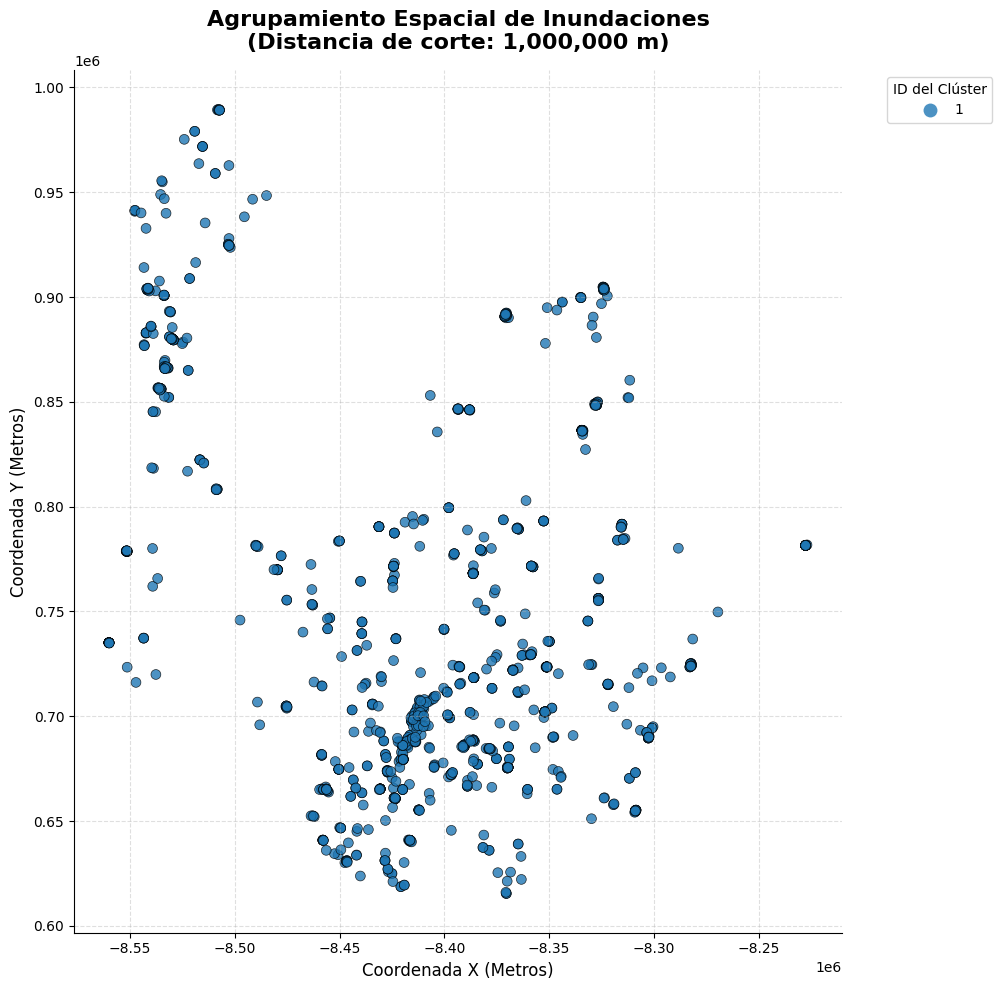

Distribución de eventos por clúster:
cluster
1    1270
Name: count, dtype: int64


In [ ]:
coordenadas = np.column_stack((
    gdf_proyectado.geometry.centroid.x,
    gdf_proyectado.geometry.centroid.y
))

# Nota: Si quisieras agrupar por variables numéricas (ej. 'VIVIENDASD') en lugar de espacio,
# reemplazarías 'coordenadas' por: gdf_proyectado[['VIVIENDASD']].fillna(0).values

# 2. Calcular la matriz de enlace (Linkage Matrix)
# El método 'ward' es excelente porque minimiza la varianza dentro de los clústeres.
# Al usar coordenadas proyectadas, las distancias calculadas serán directamente en metros.
Z = hierarchy.linkage(coordenadas, method='complete')

# 3. Configurar el lienzo y dibujar el Dendrograma
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_title('Dendrograma de Agrupamiento Espacial (Inundaciones)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Índice del Evento (ID del registro)', fontsize=12)
ax.set_ylabel('Distancia de Agrupamiento (Metros)', fontsize=12)

# Crear el dendrograma
dendro = hierarchy.dendrogram(
    Z,
    ax=ax,
    leaf_rotation=90.,       # Rota las etiquetas del eje X para que sean legibles
    leaf_font_size=8.,       # Tamaño de las etiquetas de las "hojas"
    color_threshold=None     # scipy coloreará automáticamente los clústeres principales
)

# 4. Limpieza visual (Estilo similar a tus gráficos anteriores)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.6, zorder=0)

plt.tight_layout()
plt.show()

# 1. Definir la distancia de corte y obtener las etiquetas de los clústeres
distancia_corte = 1e6
# criterion='distance' forma clústeres de modo que la distancia entre observaciones 
# originales dentro del mismo clúster no sea mayor al umbral dado.
gdf_proyectado['cluster'] = fcluster(Z, t=distancia_corte, criterion='distance')

# Convertir la columna del clúster a tipo 'category' para que el mapa use colores discretos
gdf_proyectado['cluster'] = gdf_proyectado['cluster'].astype(str)

# 2. Configurar el lienzo para el mapa
fig, ax = plt.subplots(figsize=(12, 10))
ax.set_title(f'Agrupamiento Espacial de Inundaciones\n(Distancia de corte: {distancia_corte:,.0f} m)', 
             fontsize=16, fontweight='bold', pad=15)

# 3. Dibujar el mapa
# Asumiendo que gdf_proyectado tiene geometrías de puntos o polígonos
gdf_proyectado.plot(
    column='cluster',
    categorical=True,
    cmap='tab20',          # Paleta de colores discretos ideal para categorías
    legend=True,
    legend_kwds={'title': 'ID del Clúster', 'bbox_to_anchor': (1.05, 1), 'loc': 'upper left'},
    markersize=50,         # Ajusta si son puntos
    alpha=0.8,
    edgecolor='k',
    linewidth=0.5,
    ax=ax
)

# 4. Limpieza visual
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Coordenada X (Metros)', fontsize=12)
ax.set_ylabel('Coordenada Y (Metros)', fontsize=12)
ax.grid(linestyle='--', alpha=0.4, zorder=0)

plt.tight_layout()
plt.show()

# Opcional: Imprimir un pequeño resumen estadístico de la agrupación
print("Distribución de eventos por clúster:")
print(gdf_proyectado['cluster'].value_counts().sort_index())